# Random Forest
Addestriamo nuovamente un modello come visto per la Logistic Regression usando il metodo delle Random Forests. Interpretiamo la domanda esattamente come espresso per la Logistic Regression.

In [1]:
# importiamo i moduli necessari
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn import metrics
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

%load_ext autoreload
%autoreload 2
import sys
sys.path.append('../..')

import src.class_funcs as fs

In [2]:
# scelta del seed random per la riproducibilità dei risultati
seed = 58327419

## Classificazione binaria

Come spiegato nel notebook relativo alla regressione logistica, cominciamo l'analisi studiando una versione binaria del problema. In questo caso poniamo il threshold tra le due categorie di qualità dell'aria a 40, ovvero la soglia tra le categorie 'fair' e 'moderate'. 

Seppure la colonna 'winds_spd' sia molto correlata con gli inquinanti, contenendo diversi NaN, scegliamo per il momento di escluderla. Questa scelta è approfondita nel notebook di appendice.

In [3]:
# importiamo il dataframe creato precedentemente appositamente per questo studio
binary_class_df = pd.read_csv('../../data/processed/dataset_binary_class_processed.csv')

# togliamo la colonna 'winds_spd'
binary_class_df.drop('winds_spd', axis=1, inplace=True)

binary_class_df.head()

,station_Borgo Valsugana,station_Monte Gaza,station_Parco S. Chiara,station_Piana Rotaliana,station_Riva del Garda,station_Rovereto,station_Via Bolzano,elevation,day,cos_week_day,...,PM10_3,NO2_3,AQI_3,power_area_50_3,temperature,precipitation,PM10_diff,NO2_diff,AQI_diff,target
0,1,0,0,0,0,0,0,410,1,-0.900969,...,19.0,19.0,24.0,17.861264,10.950,0.0,1.0,1.0,4.0,1
1,1,0,0,0,0,0,0,410,1,-0.900969,...,20.0,17.0,22.0,14.669913,11.000,0.0,-2.0,-2.0,0.0,1
2,1,0,0,0,0,0,0,410,1,-0.900969,...,21.0,18.0,26.0,16.969367,10.925,0.0,5.0,0.0,6.0,1
3,1,0,0,0,0,0,0,410,1,-0.900969,...,19.0,16.0,26.0,15.329278,10.950,0.0,-5.0,-1.0,-10.0,1
4,1,0,0,0,0,0,0,410,1,-0.900969,...,24.0,16.0,32.0,17.519438,11.550,0.0,3.0,0.0,2.0,1


## Pipeline

Come nel notebook 04, usiamo una pipeline per semplificare il lavoro di riscalare i dati quando si cambia l'insieme di training all'interno della cross validation. Inoltre, lavorare con una pipeline rende più diretto il processo di allenamento del modello. A dire il vero, poiché lavoriamo con un algoritmo Random Forest, la standardizzazione dei dati non è necessaria dato che il modello cerca unicamente di trovare le dicotomie migliori. Tuttavia, sia per mantenere la coerenza del nostro workflow che per garantire la stessa importanza per tutte le feature, scegliamo comunque di effetture la standardizzazione.

In [4]:
# individuiamo le colonne numeriche e quelle non numeriche
non_num_features = [col for col in binary_class_df.columns if col.startswith('station_')]
num_features = binary_class_df.columns.difference(non_num_features + ['target'])

# per il preprocessing usiamo lo stesso schema del modello logistico
preprocessor_binary = ColumnTransformer(transformers=[('num', StandardScaler(), num_features), ('one-hot', 'passthrough', non_num_features)])

# Time Series Cross Validation
tscv = TimeSeriesSplit(n_splits=5)

# pipeline con Random Forest
pipeline_rfc_2 = Pipeline([('preprocessor', preprocessor_binary), ('classifier', RandomForestClassifier(random_state=seed))])

# griglia degli iperparametri
param_grid_rfc = {'classifier__n_estimators': [100, 200, 500],
                'classifier__max_depth': [5, 10, None],
                'classifier__min_samples_leaf': [1, 2, 5],
                'classifier__max_features': [None, 'sqrt', 'log2'],
                'classifier__class_weight': [None, 'balanced']}

# ricerca degli iperparametri
rfc_2 = GridSearchCV(estimator=pipeline_rfc_2,                                  # usiamo Random Forest con la pipeline integrata
                    param_grid=param_grid_rfc,                                  # cerchiamo gli iperparametri migliori
                    scoring=metrics.make_scorer(metrics.matthews_corrcoef),     # classi sbilanciate, nessuna preferenza per fpr o fnr -> usiamo MCC
                    cv=tscv,                                                    # come spiegato nel notebook 04, dobbiamo fare la CV in ordine cronologico
                    n_jobs=-1,                                                  # usiamo la massima potenza disponibile nella CPU
                    refit=True)                                                 # vogliamo poi allenare il modello con i migliori iperparametri

### Train, Valid, Test split

Dividiamo quindi il dataset in train (70%), valid (15%) e test (15%). In un primo momento alleniamo il modello su train e usiamo GridSearchCV per trovare gli iperparametri migliori. In seguito ottimizziamo il threshold decisionale su valid. Dopo aver fatto ciò, rialleniamo il modello su test + valid utilizzando gli iperparametri ricavati e adottando alla fine il threshold trovato precedentemente, che consideriamo ancora valido. Infine, testiamo il modello ottenuto su test per ricavare $E_{out}$.

In [5]:
# troviamo le colonne con le features
feature_cols = list(num_features) + list(non_num_features)

# creiamo train, valid e test
bi_X_train, bi_X_valid, bi_X_test, bi_y_train, bi_y_valid, bi_y_test = fs.get_train_valid_test(binary_class_df, 0.7, 0.15, feature_cols)

bi_X_train.head()

,AQI_1,AQI_2,AQI_3,AQI_diff,NO2_1,NO2_2,NO2_3,NO2_diff,PM10_1,PM10_2,...,sin_hour,sin_week_day,temperature,station_Borgo Valsugana,station_Monte Gaza,station_Parco S. Chiara,station_Piana Rotaliana,station_Riva del Garda,station_Rovereto,station_Via Bolzano
0,26.0,22.0,24.0,4.0,18.0,17.0,19.0,1.0,21.0,20.0,...,1.000000,-0.433884,10.950,1,0,0,0,0,0,0
1,26.0,26.0,22.0,0.0,16.0,18.0,17.0,-2.0,19.0,21.0,...,0.965926,-0.433884,11.000,1,0,0,0,0,0,0
2,32.0,26.0,26.0,6.0,16.0,16.0,18.0,0.0,24.0,19.0,...,0.866025,-0.433884,10.925,1,0,0,0,0,0,0
3,22.0,32.0,26.0,-10.0,15.0,16.0,16.0,-1.0,19.0,24.0,...,0.707107,-0.433884,10.950,1,0,0,0,0,0,0
4,24.0,22.0,32.0,2.0,15.0,15.0,16.0,0.0,22.0,19.0,...,0.500000,-0.433884,11.550,1,0,0,0,0,0,0


### Allenamento modello

In [6]:
# training
rfc_2.fit(bi_X_train, bi_y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...e=58327419))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__class_weight': [None, 'balanced'], 'classifier__max_depth': [5, 10, ...], 'classifier__max_features': [None, 'sqrt', ...], 'classifier__min_samples_leaf': [1, 2, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",make_scorer(m...hod='predict')
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",TimeSeriesSpl...est_size=None)
,"verbose ver

In [7]:
print("Best parameters:")
print(rfc_2.best_params_)
# attenzione: il miglior punteggio non è uguale all'MCC del modello finale ritrainato poiché lo score è la media degli MCC dei diversi insiemi su cui
# compiamo la cross validation
print("Best MCC:")
print(rfc_2.best_score_)

Best parameters:
{'classifier__class_weight': None, 'classifier__max_depth': 5, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 1, 'classifier__n_estimators': 200}
Best MCC:
0.8305262015769916


In [8]:
# miglior modello
best_rfc_2 = rfc_2.best_estimator_

### Studio importanza features

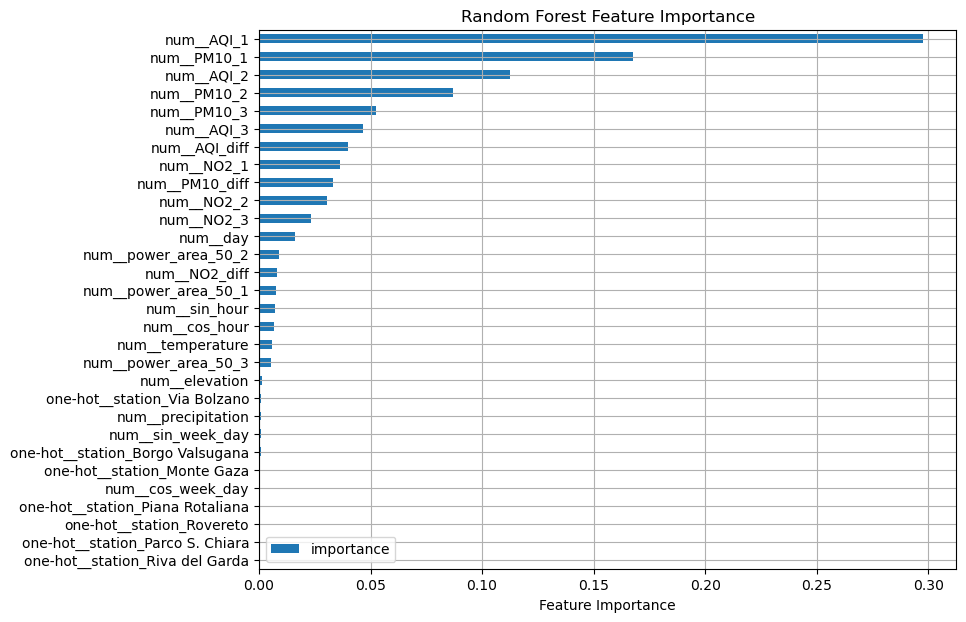

In [9]:
# tiro fuori i nomi delle feature come li ha presi il trasformatore (in questo modo non rischio di scambiare le features)
feature_names = (best_rfc_2.named_steps['preprocessor'].get_feature_names_out())

rfc_2_model = best_rfc_2.named_steps['classifier']

fs.display_importances(rfc_2_model, feature_names)

Osserviamo che le features relative alla qualità dell'aria e agli inquinanti nelle ore precedenti sono di gran lunga le più importanti. Questo chiaramente non ci stupisce visto che queste features sono causalmente e logicamente legate al nostro target in modo chiaro e marcato. Anche le differenze sono importanti ma sistematicamente meno dei dati assoluti. Anche temperatura, potenza elettrica e orario sono features piuttosto rilevanti, anche se significativamente meno rispetto a quelle discusse precedentemente. D'altra parte, le features relative alle stazioni di rilevamento sono incredibilmente poco influenti e si potrebbero probabilmente tagliare senza ridurre la validità del modello.

### Studio performance del modello

Vediamo se il training è stato efficace sui dati di train e ci chiediamo se il modello rimane buono anche su valid. Cerchiamo anche di valutare se il nostro modello ha compiuto overfitting o se siamo effettivamente riusciti ad impedire che imparasse il rumore dei dati.

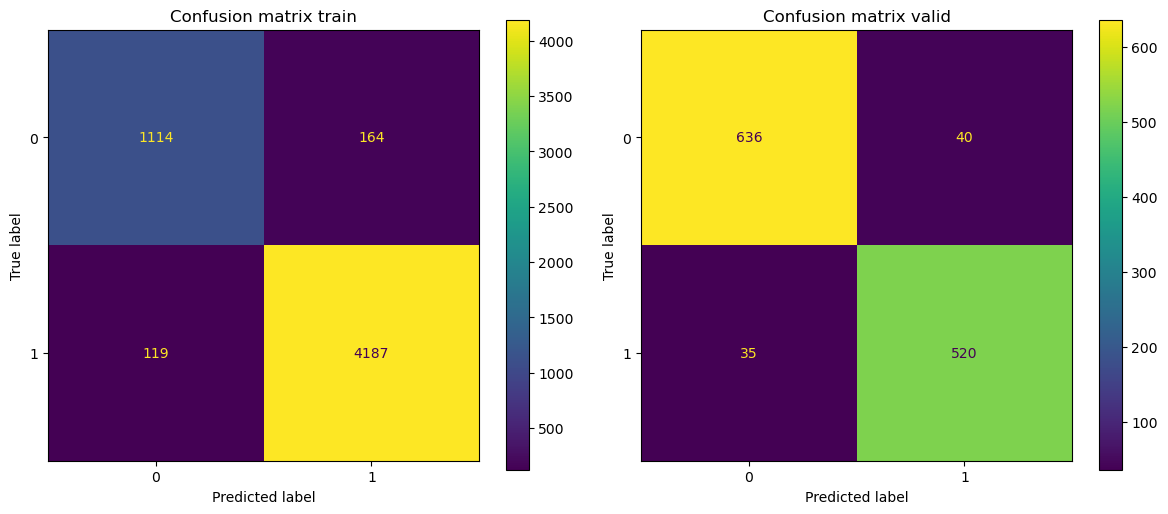

Performance del modello su train
Accuratezza:    0.94932
Precisione:     0.96231
Recall:         0.97236
F1 score:       0.96731
MCC:            0.85485
---------------------------------------------
Performance del modello su valid
Accuratezza:    0.93907
Precisione:     0.92857
Recall:         0.93694
F1 score:       0.93274
MCC:            0.87709


In [10]:
fs.display_confusion_matrix(rfc_2, 'Confusion matrix train', bi_X_train, bi_y_train, 'Confusion matrix valid', bi_X_valid, bi_y_valid)

print('Performance del modello su train')
fs.get_performance_param(rfc_2, bi_X_train, bi_y_train)
print('---------------------------------------------')
print('Performance del modello su valid')
fs.get_performance_param(rfc_2, bi_X_valid, bi_y_valid)

Il modello produce predizioni abbastanza affidabili, con accuratezza, precisione, sensibilità e F1-score sopra 0.9 sia in train che in valid. Chiaramente il modello è più potente quando lavora con i dati di train, dopotutto sono quelli su cui è stato allenato; tuttavia, rimane buono anche su valid e per questo escludiamo l'ipotesi di aver compiuto un overfitting significativo dei dati. 

Come già discusso, i dati usati per valid sono raccolti nel periodo antecedente a Natale, dove la qualità dell'aria peggiora drasticamente e, per questo motivo, la proporzione di qualità dell'aria buona (1) e cattiva (0) è differente nel valid rispetto che nel train. Questo trend, come nello studio orario binario con Logistic Regression, non sembra intaccare pesantemente la predittività del modello.


### Ottimizzazione del threshold

Cerchiamo adesso di accordare il threshold decisionale del nostro modello in modo da massimizzare l'MCC. Questa procedura è pericolosa poiché stiamo ottimizzando il threshold su un campione che non sembra seguire la stessa distribuzione del train e questo introduce la possibilità di adattare troppo il nostro modello a dei dati che non sono ben rappresentativi dell'insieme totale. Tuttavia, visti i risultati già buoni del modello sull'insieme di validazione, riteniamo questa operazione lecita.

In [11]:
bi_y_proba_va = best_rfc_2.predict_proba(bi_X_valid)[:, 1]

max_MCC_score = -1
best_thr = None

thr = np.linspace(0, 1, 1001)

for t in thr:
    bi_y_pred = (bi_y_proba_va >= t).astype(int)
    MCC_score = metrics.matthews_corrcoef(bi_y_valid, bi_y_pred)

    if (MCC_score > max_MCC_score):
        max_MCC_score = MCC_score
        best_thr = t


print(f'Threshold MCC: {best_thr:.5f}')
print(f'Maximum MCC:   {max_MCC_score:.5f}')

Threshold MCC: 0.43000
Maximum MCC:   0.87933


Un threshold vicino a 0.5 ci indica che il modello non necessita una modifica drastica della soglia decisionale e un buon valore di MCC ci porta a pensare che questa operazione sia effettivamente lecita. Dopo aver ottimizzato gli iperparametri e il threshold, procediamo a riallenare il modello su train + valid utilizzando gli iperparametri e il threshold trovati.

### Retrain su train + valid e studio di test

In [12]:
# uniamo train e valid
bi_X_train_valid = pd.concat([bi_X_train, bi_X_valid], ignore_index=True)
bi_y_train_valid = pd.concat([bi_y_train, bi_y_valid], ignore_index=True)

# rialleniamo il modello migliore ottenuto prima, in modo da usare gli iperparametri migliori
# inoltre, siccome la pipeline è già inclusa, non c'è bisogno di riscalare il nuovo insieme di allenamento
best_rfc_2.fit(bi_X_train_valid, bi_y_train_valid)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('one-hot', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transf

### Valutazione finale della performance del modello

Performance del modello su test
Accuratezza:    0.95385
Precisione:     0.95489
Recall:         0.98341
F1 score:       0.96894
MCC:            0.88069


<Figure size 1200x500 with 0 Axes>

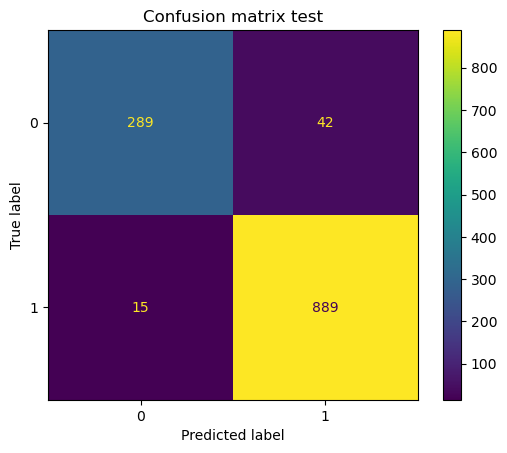

In [13]:
fs.display_confusion_matrix(best_rfc_2, 'Confusion matrix test', bi_X_test, bi_y_test, thr=best_thr)

print('Performance del modello su test')
fs.get_performance_param(best_rfc_2, bi_X_test, bi_y_test, thr=best_thr)

Il modello allenato produce previsioni molto affidabili anche su dati nuovi, con un MCC pari a 0.881. Accuratezza, precisione, sensibilità e F1-score sono tutti sopra 0.95, mostrando un modello molto solido sotto tutti i punti di vista. 

Pensiamo che il particolare trend della qualità dell'aria nel corso del periodo studiato non invalidi il nostro modello. Infatti, nel Test, quando dopo Natale la qualità dell'aria torna a migliorare, il modello addestrato con il threshold di valid mantiene la sua validità, seppure l'insieme di validazione avesse una settasse il threshold su dati con una qualità dell'aria molto inferiore.

In generale, alla luce dei risultati appena osservati, confermiamo la possibilità di allenare un modello di classificazione binaria sul nostro dataset.

Possiamo dunque ritornare allo studio multiclasse e vedere se la situazione migliora rispetto alla Logistic Regression.

## Classificazione a 5 classi

Ripetiamo lo studio visto in precedenza per 5 classi. Chiaramente, aumentando il numero di classi, si riduce la quantità di dati per classe e anche gli alberi decisionali diventano più complessi e proni ad errori. Per questo motivo, ci aspettiamo che il modello abbia una performance peggiore rispetto a quello allenato per il problema binario, ma speriamo che rimanga comunque buono. 

Poiché la classificazione non è più binaria, non è più presente un solo threshold decisionale, ma svariati. Per questo motivo, scegliamo di non effettuare il passaggio dell'ottimizzazione del threshold, eliminiamo l'insieme di validazione e testiamo direttamente il modello allenato su train su test.

In [14]:
# importiamo il dataframe creato precedentemente appositamente per questo studio
multiclass_df = pd.read_csv('../../data/processed/dataset_multiclass_processed.csv')

# togliamo la colonna 'winds_spd'
multiclass_df.drop('winds_spd', axis=1, inplace=True)

multiclass_df.head()

,station_Borgo Valsugana,station_Monte Gaza,station_Parco S. Chiara,station_Piana Rotaliana,station_Riva del Garda,station_Rovereto,station_Via Bolzano,elevation,day,cos_week_day,...,PM10_3,NO2_3,AQI_3,power_area_50_3,temperature,precipitation,PM10_diff,NO2_diff,AQI_diff,target
0,1,0,0,0,0,0,0,410,1,-0.900969,...,19.0,19.0,24.0,17.861264,10.950,0.0,1.0,1.0,4.0,fair
1,1,0,0,0,0,0,0,410,1,-0.900969,...,20.0,17.0,22.0,14.669913,11.000,0.0,-2.0,-2.0,0.0,fair
2,1,0,0,0,0,0,0,410,1,-0.900969,...,21.0,18.0,26.0,16.969367,10.925,0.0,5.0,0.0,6.0,fair
3,1,0,0,0,0,0,0,410,1,-0.900969,...,19.0,16.0,26.0,15.329278,10.950,0.0,-5.0,-1.0,-10.0,fair
4,1,0,0,0,0,0,0,410,1,-0.900969,...,24.0,16.0,32.0,17.519438,11.550,0.0,3.0,0.0,2.0,fair


### Pipeline

Replichiamo la procedura svolta prima, per mantenere la coerenza del nostro algoritmo.

Come nello studio con la logistic regression, le classi sono molto sbilanciate, con un intero ordine di grandezza di differenza tra la maggiore e la minore. Questo ci induce a pensare che, per ottenere un buon risultato per tutte le classi, convenga usare class_weight = 'balanced'. Testeremo questa ipotesi confrontandola con i risultati di GridSearchCV.

In [15]:
# individuiamo le colonne numeriche e quelle non numeriche
non_num_features = [col for col in multiclass_df.columns if col.startswith('station_')]
num_features = multiclass_df.columns.difference(non_num_features + ['target'])

# per il preprocessing usiamo lo stesso schema del modello logistico
preprocessor_multi = ColumnTransformer(transformers=[('num', StandardScaler(), num_features), ('one-hot', 'passthrough', non_num_features)])

# Time Series Cross Validation
tscv = TimeSeriesSplit(n_splits=5)

# pipeline con Random Forest
pipeline_rfc_5 = Pipeline([('preprocessor', preprocessor_multi), ('classifier', RandomForestClassifier(random_state=seed))])

# griglia degli iperparametri
param_grid_rfc = {'classifier__n_estimators': [100, 200, 500],
                'classifier__max_depth': [5, 10, None],
                'classifier__min_samples_leaf': [1, 2, 5],
                'classifier__max_features': [None, 'sqrt', 'log2'],
                'classifier__class_weight': [None, 'balanced']}

# ricerca degli iperparametri
rfc_5 = GridSearchCV(estimator=pipeline_rfc_5,                                  # usiamo Random Forest con la pipeline integrata
                    param_grid=param_grid_rfc,                                  # cerchiamo gli iperparametri migliori
                    scoring=metrics.make_scorer(metrics.matthews_corrcoef),     # classi sbilanciate, nessuna preferenza per fpr o fnr -> usiamo MCC
                    cv=tscv,                                                    # come spiegato nel notebook 04, dobbiamo fare la CV in ordine cronologico
                    n_jobs=-1,                                                  # usiamo la massima potenza disponibile nella CPU
                    refit=True)                                                 # vogliamo poi allenare il modello con i migliori iperparametri

### Train Test split

In questo caso, non essendo interessati ad ottimizzare il threshold decisionale, creiamo solo due insiemi: train (80% dei dati) dove alleniamo il modello e test (20%) dove ne valutiamo la performance alla fine.

In [16]:
# splittiamo il dataset
feature_cols = list(num_features) + list(non_num_features)

# creiamo train e test
multi_X_train, _, multi_X_test, multi_y_train, _, multi_y_test = fs.get_train_valid_test(multiclass_df, 0.8, 0.0, feature_cols)

multi_X_train.head()

,AQI_1,AQI_2,AQI_3,AQI_diff,NO2_1,NO2_2,NO2_3,NO2_diff,PM10_1,PM10_2,...,sin_hour,sin_week_day,temperature,station_Borgo Valsugana,station_Monte Gaza,station_Parco S. Chiara,station_Piana Rotaliana,station_Riva del Garda,station_Rovereto,station_Via Bolzano
0,26.0,22.0,24.0,4.0,18.0,17.0,19.0,1.0,21.0,20.0,...,1.000000,-0.433884,10.950,1,0,0,0,0,0,0
1,26.0,26.0,22.0,0.0,16.0,18.0,17.0,-2.0,19.0,21.0,...,0.965926,-0.433884,11.000,1,0,0,0,0,0,0
2,32.0,26.0,26.0,6.0,16.0,16.0,18.0,0.0,24.0,19.0,...,0.866025,-0.433884,10.925,1,0,0,0,0,0,0
3,22.0,32.0,26.0,-10.0,15.0,16.0,16.0,-1.0,19.0,24.0,...,0.707107,-0.433884,10.950,1,0,0,0,0,0,0
4,24.0,22.0,32.0,2.0,15.0,15.0,16.0,0.0,22.0,19.0,...,0.500000,-0.433884,11.550,1,0,0,0,0,0,0


### Allenamento del modello

In [17]:
# training
rfc_5.fit(multi_X_train, multi_y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...e=58327419))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__class_weight': [None, 'balanced'], 'classifier__max_depth': [5, 10, ...], 'classifier__max_features': [None, 'sqrt', ...], 'classifier__min_samples_leaf': [1, 2, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",make_scorer(m...hod='predict')
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",TimeSeriesSpl...est_size=None)
,"verbose ver

In [18]:
print("Best parameters:")
print(rfc_5.best_params_)
# attenzione: il miglior punteggio non è uguale all'MCC del modello finale ritrainato poiché lo score è la media degli MCC dei diversi insiemi su cui
# compiamo la cross validation
print("Best MCC:")
print(rfc_5.best_score_)

Best parameters:
{'classifier__class_weight': None, 'classifier__max_depth': 5, 'classifier__max_features': None, 'classifier__min_samples_leaf': 5, 'classifier__n_estimators': 500}
Best MCC:
0.7432910229398416


Notiamo che la nostra iniziale ipotesi, cioè che per avere il risultato migliore sarebbe stato necessario imporre class_weight = 'balanced', si rivela errata poiché il valore di class_weight che produce l'MCC migliore è None. 

In [19]:
# miglior modello
best_rfc_5 = rfc_5.best_estimator_

### Studio importanza features

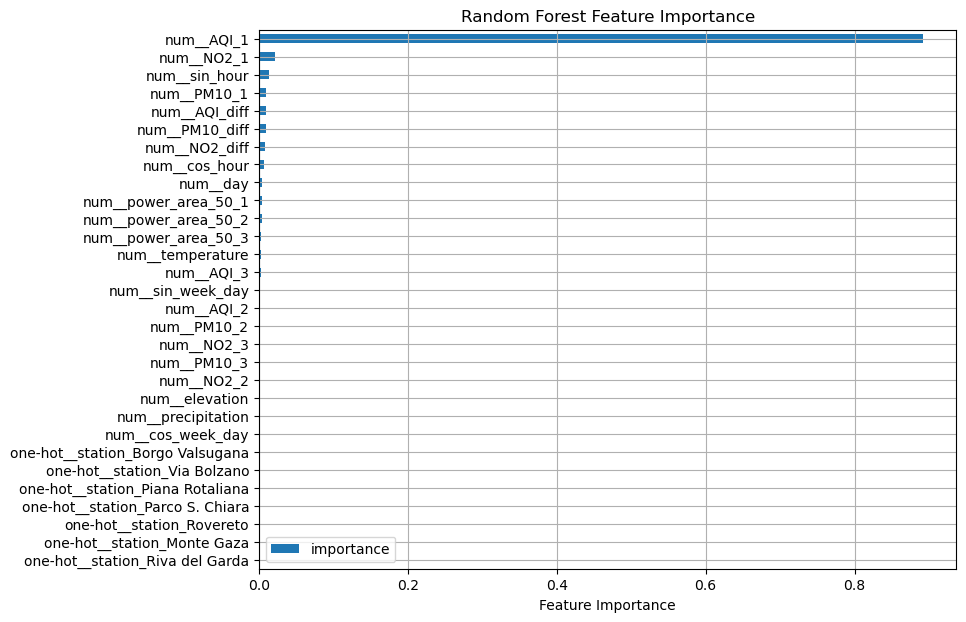

In [20]:
# tiro fuori i nomi delle feature come li ha presi il trasformatore (in questo modo non rischio di scambiare le features)
feature_names = (best_rfc_5.named_steps['preprocessor'].get_feature_names_out())

rfc_5_model = best_rfc_5.named_steps['classifier']

fs.display_importances(rfc_5_model, feature_names)

Vediamo che le feature più importanti rimangono più o meno quelle viste precedentemente. Tuttavia, rispetto a prima num_AQI_1 diventa di gran lunga la feature più importante, a tal punto che la previsione fa affidamento quasi unicamente su quella feature. Questo ci porta a pensare che il modello potrebbe non essere ottimale visto che, nel caso precedente, si otteneva un ottimo risultato ed anche altre feature erano rilevanti.

### Studio performance del modello

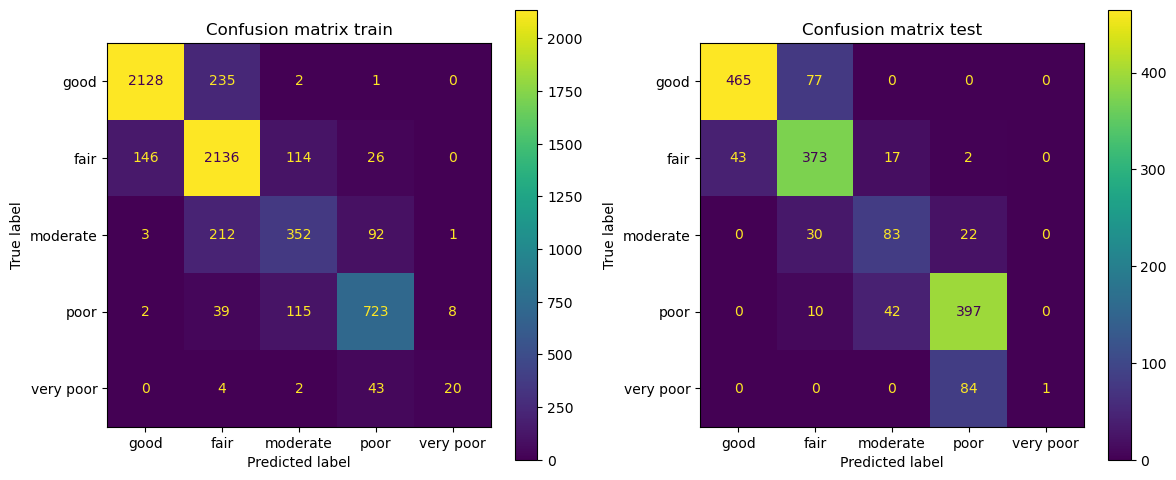

Performance del modello su train
Accuratezza:    0.83682
Precisione:     0.83520
Recall:         0.83682
F1 score:       0.83428
MCC:            0.76252
---------------------------------------------
Performance del modello su test
Accuratezza:    0.80134
Precisione:     0.81661
Recall:         0.80134
F1 score:       0.78217
MCC:            0.73021


In [21]:
class_order = ['good', 'fair', 'moderate', 'poor', 'very poor']
fs.display_confusion_matrix_multiclass(rfc_5, class_order, 'Confusion matrix train', multi_X_train, multi_y_train, 'Confusion matrix test', multi_X_test, multi_y_test)

print('Performance del modello su train')
fs.get_performance_param(rfc_5, multi_X_train, multi_y_train, binary=False)
print('---------------------------------------------')
print('Performance del modello su test')
fs.get_performance_param(rfc_5, multi_X_test, multi_y_test, binary=False)

Notiamo che, rispetto a prima, il modello ha una performance decisamente peggiore. Quello che ci fa preoccupare maggiormente, tuttavia, non sono tanto i valori bassi dei vari indici di qualità del modello quanto il fatto che, stando alla matrice di predizione, su 85 dati in 'very poor' ben 84 vengono classificati erroneamente.

## Classificazione a 4 classi

Visto che, a quanto pare, il modello non riesce a distinguere bene tra le categorie 'poor' e 'very poor', scegliamo di provare a riaddestrare il modello unificando queste due categorie. Nonostante nel notebook precedente questo approccio non abbia portato buoni risutati, ci aspettiamo che un modello più raffinato come il Random Forest possa migliorare in questo caso. Da un punto di vista pratico, poiché entrambe le classi si trovano al di sopra del limite consigliato per la salute, il comportamento da adottare in entrambe le situazioni è essenzialmente uguale e pertanto perdere questa distinzione è poco dannoso.

### Pipeline

In [22]:
# per il preprocessing usiamo lo stesso schema del modello logistico
preprocessor_four = ColumnTransformer(transformers=[('num', StandardScaler(), num_features), ('one-hot', 'passthrough', non_num_features)])

# Time Series Cross Validation
tscv = TimeSeriesSplit(n_splits=5)

# pipeline con Random Forest
pipeline_rfc_4 = Pipeline([('preprocessor', preprocessor_four), ('classifier', RandomForestClassifier(random_state=seed))])

# griglia degli iperparametri
param_grid_rfc = {'classifier__n_estimators': [100, 200, 500],
                'classifier__max_depth': [5, 10, None],
                'classifier__min_samples_leaf': [1, 2, 5],
                'classifier__max_features': [None, 'sqrt', 'log2'],
                'classifier__class_weight': [None, 'balanced']}

# ricerca degli iperparametri
rfc_4 = GridSearchCV(estimator=pipeline_rfc_4,                                  # usiamo Random Forest con la pipeline integrata
                    param_grid=param_grid_rfc,                                  # cerchiamo gli iperparametri migliori
                    scoring=metrics.make_scorer(metrics.matthews_corrcoef),     # classi sbilanciate, nessuna preferenza per fpr o fnr -> usiamo MCC
                    cv=tscv,                                                    # come spiegato nel notebook 04, dobbiamo fare la CV in ordine cronologico
                    n_jobs=-1,                                                  # usiamo la massima potenza disponibile nella CPU
                    refit=True)                                                 # vogliamo poi allenare il modello con i migliori iperparametri

### Train, Test split

In [23]:
# usiamo gli stessi insiemi di prima ma cambiamo very poor in poor
feature_cols = list(num_features) + list(non_num_features)

# creiamo train e test
four_X_train = multi_X_train
four_X_test = multi_X_test
four_y_train = multi_y_train
four_y_test = multi_y_test

# accorpiamo poor e very poor
four_y_train = four_y_train.replace('very poor', 'poor')
four_y_test = four_y_test.replace('very poor', 'poor')

four_X_train.head()

,AQI_1,AQI_2,AQI_3,AQI_diff,NO2_1,NO2_2,NO2_3,NO2_diff,PM10_1,PM10_2,...,sin_hour,sin_week_day,temperature,station_Borgo Valsugana,station_Monte Gaza,station_Parco S. Chiara,station_Piana Rotaliana,station_Riva del Garda,station_Rovereto,station_Via Bolzano
0,26.0,22.0,24.0,4.0,18.0,17.0,19.0,1.0,21.0,20.0,...,1.000000,-0.433884,10.950,1,0,0,0,0,0,0
1,26.0,26.0,22.0,0.0,16.0,18.0,17.0,-2.0,19.0,21.0,...,0.965926,-0.433884,11.000,1,0,0,0,0,0,0
2,32.0,26.0,26.0,6.0,16.0,16.0,18.0,0.0,24.0,19.0,...,0.866025,-0.433884,10.925,1,0,0,0,0,0,0
3,22.0,32.0,26.0,-10.0,15.0,16.0,16.0,-1.0,19.0,24.0,...,0.707107,-0.433884,10.950,1,0,0,0,0,0,0
4,24.0,22.0,32.0,2.0,15.0,15.0,16.0,0.0,22.0,19.0,...,0.500000,-0.433884,11.550,1,0,0,0,0,0,0


### Allenamento modello

In [24]:
# training
rfc_4.fit(four_X_train, four_y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...e=58327419))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__class_weight': [None, 'balanced'], 'classifier__max_depth': [5, 10, ...], 'classifier__max_features': [None, 'sqrt', ...], 'classifier__min_samples_leaf': [1, 2, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",make_scorer(m...hod='predict')
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",TimeSeriesSpl...est_size=None)
,"verbose ver

In [25]:
print("Best parameters:")
print(rfc_4.best_params_)
# attenzione: il miglior punteggio non è uguale all'MCC del modello finale ritrainato poiché lo score è la media degli MCC dei diversi insiemi su cui
# compiamo la cross validation
print("Best MCC:")
print(rfc_4.best_score_)

Best parameters:
{'classifier__class_weight': None, 'classifier__max_depth': 5, 'classifier__max_features': None, 'classifier__min_samples_leaf': 5, 'classifier__n_estimators': 500}
Best MCC:
0.7564077259087048


In [26]:
# miglior modello
best_rfc_4 = rfc_4.best_estimator_

### Studio importanza features

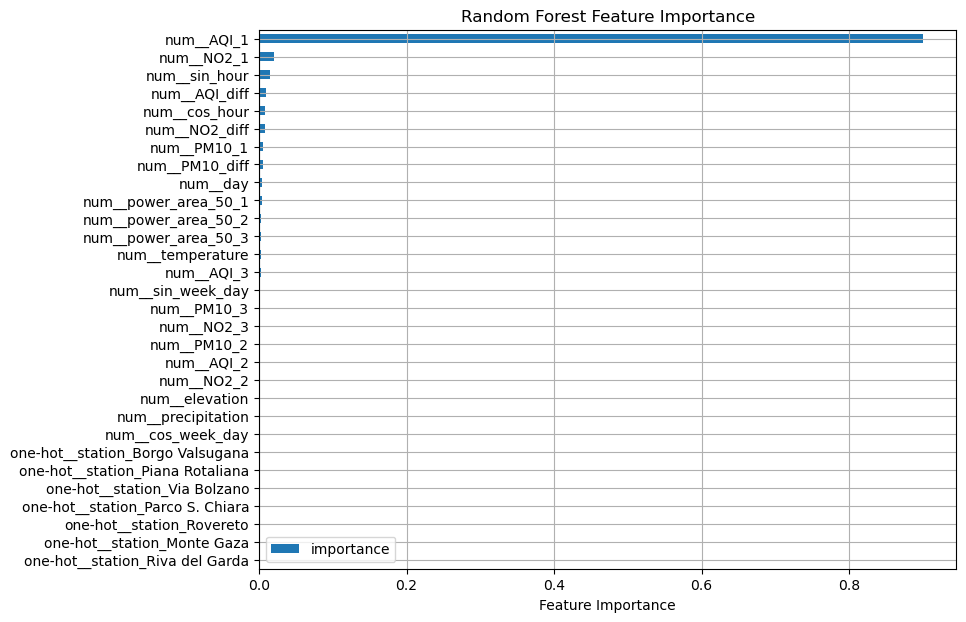

In [27]:
# tiro fuori i nomi delle feature come li ha presi il trasformatore (in questo modo non rischio di scambiare le features)
feature_names = (best_rfc_4.named_steps['preprocessor'].get_feature_names_out())

rfc_4_model = best_rfc_4.named_steps['classifier']

fs.display_importances(rfc_4_model, feature_names)

Il modello è molto simile a prima come importanza nelle feature, rimanendo completamente sbilanciato verso num_AQI_1.

### Studio confusion matrix

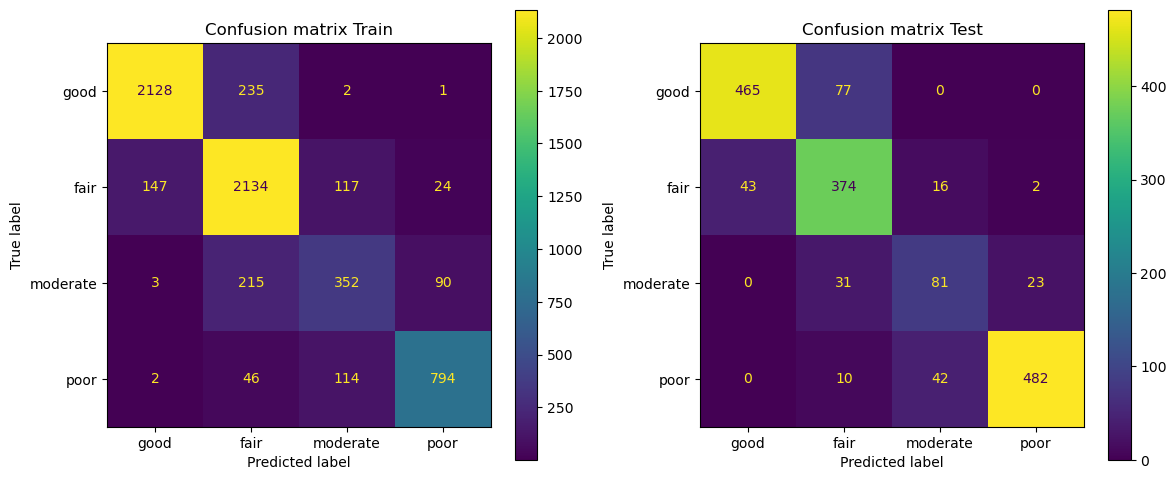

Performance del modello su train
Accuratezza:    0.84447
Precisione:     0.84411
Recall:         0.84447
F1 score:       0.84334
MCC:            0.77297
---------------------------------------------
Performance del modello su test
Accuratezza:    0.85176
Precisione:     0.85852
Recall:         0.85176
F1 score:       0.85381
MCC:            0.79301


In [28]:
class_order = ['good', 'fair', 'moderate', 'poor']
fs.display_confusion_matrix_multiclass(rfc_4, class_order, 'Confusion matrix Train', four_X_train, four_y_train, 'Confusion matrix Test', four_X_test, four_y_test)

print('Performance del modello su train')
fs.get_performance_param(rfc_4, four_X_train, four_y_train, binary=False)
print('---------------------------------------------')
print('Performance del modello su test')
fs.get_performance_param(rfc_4, four_X_test, four_y_test, binary=False)

Vediamo che la matrice di confusione sembra molto migliorata e anche l'MCC aumenta da 0.730 a 0.793. Questo incremento non è drastico, ma rimane comunque sensibile. 

Inoltre, rispetto alla Logistic Regression il modello sembra predire in modo molto più pulito, con ogni classe che viene sempre predetta più correttamente che non. In particolare è interessante il caso della classe 'good', che, mentre prima veniva predetta in modo pessimo, adesso vede il modello sbagliare solo una volta su sette (all'incirca).

Anche se tutte le metriche aumentano rispetto al modello a 5 classi, rimangono d'altro canto inferiori a quelle della classificazione binaria. Questo conferma l'intuizione secondo cui la qualità del modello cala all'aumentare del numero di classi. Chiaramente ciascuno dei modelli ha i propri punti di forza e le proprie debolezze e può essere vantaggioso in una data situazione. Detto ciò, se dovessimo sceglierne uno da usare in generale, propenderemmo chiaramente verso il modello binario a causa della sua maggiore affidabilità. Le informazioni che il modello binario produce sono più semplici ma comunque abbastanza chiare da trarre consigli comportamentali per la popolazione e riteniamo che la maggiore affidabilità abbia un peso positivo maggiore del peso negativo dato dalla perdita di sfumature sulle previsioni.

Con questo si chiude quindi lo studio orario e si passa a discutere lo studio giornaliero, sperando in previsioni altrettanto buone.

## Classificazione giornaliera

Dopo aver studiato le predizioni che siamo capaci di compiere ora per ora, ci concentriamo sul predire la qualità dell'aria di un dato giorno a partire dai dati relativi ai giorni precedenti, come spiegato nel notebook 04. Con le informazioni a nostra disposizione questo problema appare decisamente più difficile poiché, fissata una stazione, ad ogni giorno non corrispondono 24 punti bensì 1. Come precedentemente studiamo pertanto il problema binario.

In [29]:
daily_class_df = pd.read_csv('../../data/processed/dataset_daily_class_processed.csv')

daily_class_df.head()

,day,cos_week_day,sin_week_day,PM10_mean_1,NO2_mean_1,daily_AQI_1,power_area_50_1,PM10_mean_2,NO2_mean_2,daily_AQI_2,power_area_50_2,PM10_mean_diff_1,NO2_mean_diff_1,daily_AQI_diff_1,PM10_mean_diff_2,NO2_mean_diff_2,daily_AQI_diff_2,temperature,precipitation,target
0,4,1.000000,0.000000,23.652174,18.826087,31.478261,17.478475,28.869565,21.086957,59.058824,18.197335,-5.217391,-2.260870,-27.580563,-2.086957,-0.086957,3.826087,10.796739,0.126087,1
1,5,0.623490,0.781831,14.739130,26.739130,16.695652,37.200400,23.652174,18.826087,31.478261,17.478475,-8.913043,7.913043,-14.782609,-14.130435,5.652174,-42.363171,7.609783,0.028261,1
2,6,-0.222521,0.974928,17.000000,25.913043,23.130435,37.421266,14.739130,26.739130,16.695652,37.200400,2.260870,-0.826087,6.434783,-6.652174,7.086957,-8.347826,9.641304,0.000000,1
3,7,-0.900969,0.433884,14.739130,26.956522,16.521739,35.957377,17.000000,25.913043,23.130435,37.421266,-2.260870,1.043478,-6.608696,0.000000,0.217391,-0.173913,9.980435,0.000000,1
4,8,-0.900969,-0.433884,26.086957,27.260870,32.956522,37.366761,14.739130,26.956522,16.521739,35.957377,11.347826,0.304348,16.434783,9.086957,1.347826,9.826087,8.371739,0.000000,0


## Pipeline

In [30]:
# individuiamo le colonne numeriche e quelle non numeriche
non_num_features = [col for col in daily_class_df.columns if col.startswith('station_')]
num_features = daily_class_df.columns.difference(non_num_features + ['target'])

# per il preprocessing usiamo lo stesso schema del modello logistico
preprocessor_daily = ColumnTransformer(transformers=[('num', StandardScaler(), num_features), ('one-hot', 'passthrough', non_num_features)])

# Time Series Cross Validation
tscv = TimeSeriesSplit(n_splits=5)

# pipeline con Random Forest
pipeline_rfc_d = Pipeline([('preprocessor', preprocessor_daily), ('classifier', RandomForestClassifier(random_state=seed))])

# griglia degli iperparametri
param_grid_rfc = {'classifier__n_estimators': [100, 200, 500],
                'classifier__max_depth': [5, 10, None],
                'classifier__min_samples_leaf': [1, 2, 5],
                'classifier__max_features': [None, 'sqrt', 'log2'],
                'classifier__class_weight': [None, 'balanced']}

# ricerca degli iperparametri
rfc_d = GridSearchCV(estimator=pipeline_rfc_d,                                  # usiamo Random Forest con la pipeline integrata
                    param_grid=param_grid_rfc,                                  # cerchiamo gli iperparametri migliori
                    scoring=metrics.make_scorer(metrics.matthews_corrcoef),     # classi sbilanciate, nessuna preferenza per fpr o fnr -> usiamo MCC
                    cv=tscv,                                                    # come spiegato nel notebook 04, dobbiamo fare la CV in ordine cronologico
                    n_jobs=-1,                                                  # usiamo la massima potenza disponibile nella CPU
                    refit=True)                                                 # vogliamo poi allenare il modello con i migliori iperparametri

### Train, Valid, Test split

In questo caso, come avvenuto per la classificazione a 5 e a 4 classi, rinunciamo al passaggio dell'ottimizzazione del threshold. Questo non perché sia impossibile, ma a causa del trend del peggioramento della qualità dell'aria attorno alle festività. Dovendo compiere lo splitting su base cronologica, i dati in train e valid non sarebbero per niente omogenei. Anche se è vero che nel caso della classificazione binaria sulle ore questo non ha dato alcun tipo di problema, studiando i giorni abbiamo acceso ad una quantità ridottissima di dati e questo fenomeno intaccherebbe significativamente la validità del threshold trovato e, di conseguenza del modello. Per questo motivo, operiamo un train (80%) test (20%) split.

In [31]:
# splittiamo il dataset
feature_cols = list(num_features) + list(non_num_features)

# creiamo train, valid e test
day_X_train, _, day_X_test, day_y_train, _, day_y_test = fs.get_train_valid_test(daily_class_df, 0.8, 0.0, feature_cols)

day_X_train.head()

,NO2_mean_1,NO2_mean_2,NO2_mean_diff_1,NO2_mean_diff_2,PM10_mean_1,PM10_mean_2,PM10_mean_diff_1,PM10_mean_diff_2,cos_week_day,daily_AQI_1,daily_AQI_2,daily_AQI_diff_1,daily_AQI_diff_2,day,power_area_50_1,power_area_50_2,precipitation,sin_week_day,temperature
0,18.826087,21.086957,-2.260870,-0.086957,23.652174,28.869565,-5.217391,-2.086957,1.000000,31.478261,59.058824,-27.580563,3.826087,4,17.478475,18.197335,0.126087,0.000000,10.796739
1,26.739130,18.826087,7.913043,5.652174,14.739130,23.652174,-8.913043,-14.130435,0.623490,16.695652,31.478261,-14.782609,-42.363171,5,37.200400,17.478475,0.028261,0.781831,7.609783
2,25.913043,26.739130,-0.826087,7.086957,17.000000,14.739130,2.260870,-6.652174,-0.222521,23.130435,16.695652,6.434783,-8.347826,6,37.421266,37.200400,0.000000,0.974928,9.641304
3,26.956522,25.913043,1.043478,0.217391,14.739130,17.000000,-2.260870,0.000000,-0.900969,16.521739,23.130435,-6.608696,-0.173913,7,35.957377,37.421266,0.000000,0.433884,9.980435
4,27.260870,26.956522,0.304348,1.347826,26.086957,14.739130,11.347826,9.086957,-0.900969,32.956522,16.521739,16.434783,9.826087,8,37.366761,35.957377,0.000000,-0.433884,8.371739


### Allenamento modello

In [32]:
# training
rfc_d.fit(day_X_train, day_y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...e=58327419))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__class_weight': [None, 'balanced'], 'classifier__max_depth': [5, 10, ...], 'classifier__max_features': [None, 'sqrt', ...], 'classifier__min_samples_leaf': [1, 2, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",make_scorer(m...hod='predict')
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",TimeSeriesSpl...est_size=None)
,"verbose ver

In [33]:
print("Best parameters:")
print(rfc_d.best_params_)
# attenzione: il miglior punteggio non è uguale all'MCC del modello finale ritrainato poiché lo score è la media degli MCC dei diversi insiemi su cui
# compiamo la cross validation
print("Best MCC:")
print(rfc_d.best_score_)

Best parameters:
{'classifier__class_weight': 'balanced', 'classifier__max_depth': 5, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 5, 'classifier__n_estimators': 200}
Best MCC:
0.7473782503515546


In questo caso il miglior modello sembra essere quello con 'balanced'

In [34]:
# miglior modello
best_rfc_d = rfc_d.best_estimator_

### Studio importanza features

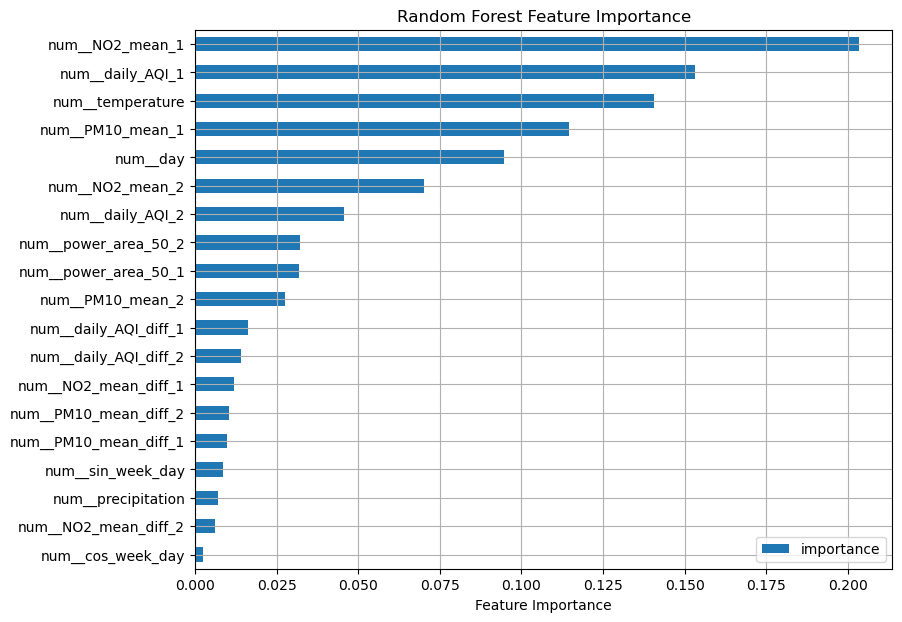

In [35]:
# tiro fuori i nomi delle feature come li ha presi il trasformatore (in questo modo non rischio di scambiare le features)
feature_names = (best_rfc_d.named_steps['preprocessor'].get_feature_names_out())

rfc_d_model = best_rfc_d.named_steps['classifier']

fs.display_importances(rfc_d_model, feature_names)

Vediamo che l'andamento delle importanze delle feature è relativamente simile rispetto a quelli dei casi precedenti. Tuttavia appare chiaro che il modello tiene conto di molte più feature rispetto al solito, invece di avere una feature incredibilmente rappresentata e le altre quasi insignificanti.

### Studio performance del modello

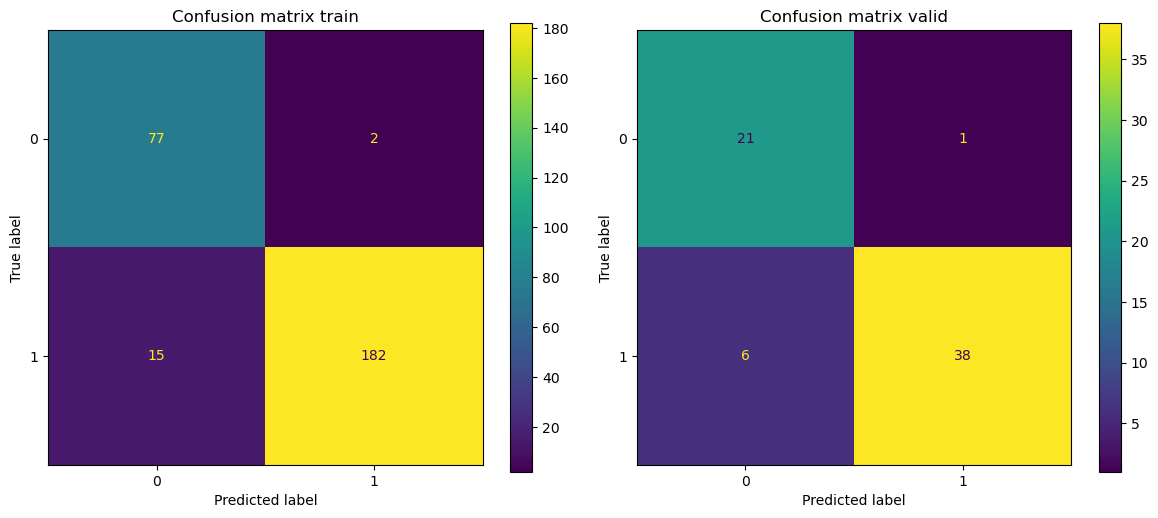

Performance del modello su train
Accuratezza:    0.93841
Precisione:     0.98913
Recall:         0.92386
F1 score:       0.95538
MCC:            0.86155
---------------------------------------------
Performance del modello su valid
Accuratezza:    0.89394
Precisione:     0.97436
Recall:         0.86364
F1 score:       0.91566
MCC:            0.78446


In [36]:
fs.display_confusion_matrix(rfc_d, 'Confusion matrix train', day_X_train, day_y_train, 'Confusion matrix valid', day_X_test, day_y_test)

print('Performance del modello su train')
fs.get_performance_param(rfc_d, day_X_train, day_y_train)
print('---------------------------------------------')
print('Performance del modello su valid')
fs.get_performance_param(rfc_d, day_X_test, day_y_test)

Il risultato dello studio è molto simile a quello della logistic regression, con un'MCC nel test di circa 0.78, contro il 0.76 precedente. Si nota però come in questo caso il risultato sul train sia migliorato di molto. Si può quindi immaginare che per la mancanza di punti il modello stia cominciando ad imparare il rumore del train e questo sicuramente inficia la sua capacità di generalizzazione. Ci aspettiamo che aumentando il numero di punti a disposizioni la Random Forest sarebbe in grado di produrre predizioni molto migliori.

In generale, la predittività del modello gionaliero rimane molto minore di quello orario, ma questo è da aspettarsi visto il numero minori di dati e l'orizzonte predittivo più distante.

Concludiamo così la classificazione e passiamo alla regressione.